# Sentinel-2 × SACP+GeoCP — Land Cover Classification Baseline

This notebook is a **controlled baseline** to the AlphaEarth land-cover pilot (`alphaearth_landcover_pilot.ipynb`).
Same 10 tiles, same ESA WorldCover labels, same XGBoost + SACP + GeoCP pipeline — **only the features change**:

| | AlphaEarth pilot | **This notebook** |
|---|---|---|
| Features | 64-band GeoFM embedding (context-aware) | 10 S2 reflectance bands + 3 spectral indices (per-pixel) |
| Year | 2020 | 2020 (May–Sept median) |
| Dim | 64 | 13 |
| Spatial context built into feature? | ✓ (pretrained on neighborhood) | ✗ (per-pixel reflectance only) |

**Hypothesis under test**: GeoCP's benefit over global conformal prediction is upper-bounded by the spatial autocorrelation of the raw APS non-conformity score (Moran's I of the residual). AlphaEarth's context-aware features should leave a very small residual I, so GeoCP barely helps. Sentinel-2's per-pixel reflectance should leave a much larger residual I, so GeoCP should help more.

The final cell produces a **side-by-side comparison** (AlphaEarth vs Sentinel-2) and the headline scatter plot `(I_raw → GeoCP improvement)` over all 10 tiles.

## 1. Setup — install dependencies

In [1]:
!pip install --quiet earthengine-api geemap rasterio xgboost scikit-learn pandas matplotlib
!pip install --quiet git+https://github.com/pengtum/GeoCP_RS.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 2. Mount Drive + authenticate Earth Engine

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import ee, os, json

PROJECT_ID = 'myproject-alpha-earth'
try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)
print('EE initialized:', PROJECT_ID)

# ---- S2 pilot workspace ----
WORK_DIR = '/content/drive/MyDrive/sentinel2_landcover_pilot_10m'
TILE_DIR = f'{WORK_DIR}/tiles'
CKPT_DIR = f'{WORK_DIR}/checkpoints'
FIG_DIR  = f'{WORK_DIR}/figures'
TIF_DIR  = f'{WORK_DIR}/_tif'
DRIVE_EXPORT_FOLDER = 'sentinel2_landcover_pilot_tif'   # Google Drive folder Export.image.toDrive writes to
for d in (TILE_DIR, CKPT_DIR, FIG_DIR, TIF_DIR):
    os.makedirs(d, exist_ok=True)

# ---- AlphaEarth pilot workspace (for side-by-side comparison) ----
AE_WORK_DIR = '/content/drive/MyDrive/alphaearth_landcover_pilot_10m'
AE_TILE_DIR = f'{AE_WORK_DIR}/tiles'
AE_CKPT_DIR = f'{AE_WORK_DIR}/checkpoints'

print('S2 WORK_DIR :', WORK_DIR)
print('AE WORK_DIR :', AE_WORK_DIR, '(exists =', os.path.isdir(AE_WORK_DIR), ')')

Mounted at /content/drive
EE initialized: myproject-alpha-earth
S2 WORK_DIR : /content/drive/MyDrive/sentinel2_landcover_pilot_10m
AE WORK_DIR : /content/drive/MyDrive/alphaearth_landcover_pilot_10m (exists = True )


## 3. Tiles — identical to the AlphaEarth pilot (10 × 10km × 10km)

In [ ]:
TILES = {
    'polk_iowa':      {'name': 'Polk County, Iowa (row-crop)',       'bbox': [-93.770, 41.560, -93.650, 41.680]},
    'lancaster_pa':   {'name': 'Lancaster, Pennsylvania (mixed ag)', 'bbox': [-76.380, 40.020, -76.260, 40.140]},
    'hartford_ct':    {'name': 'Hartford, Connecticut (urban-forest)','bbox':[-72.750, 41.720, -72.630, 41.840]},
    'everglades_fl':  {'name': 'Everglades, Florida (wetland)',      'bbox': [-80.960, 25.760, -80.840, 25.880]},
    'lubbock_tx':     {'name': 'Lubbock, Texas (irrigated dryland)', 'bbox': [-101.920, 33.520, -101.800, 33.640]},
    'sacramento_ca':  {'name': 'Sacramento Delta, California',       'bbox': [-121.580, 38.100, -121.460, 38.220]},
    'phoenix_az':     {'name': 'Phoenix, Arizona (desert-urban)',    'bbox': [-112.140, 33.460, -112.020, 33.580]},
    'yellowstone_wy': {'name': 'Yellowstone, Wyoming (forest)',      'bbox': [-110.600, 44.520, -110.480, 44.640]},
    'seattle_wa':     {'name': 'Seattle, Washington (urban-water)',  'bbox': [-122.380, 47.580, -122.260, 47.700]},
    'mississippi_la': {'name': 'Mississippi Delta, Louisiana',       'bbox': [-91.260, 29.720, -91.140, 29.840]},
}
print(f'{len(TILES)} tiles defined')

10 tiles defined


## 4. Pull Sentinel-2 median composite + ESA WorldCover labels

For each tile we build a **cloud-masked, May–Sept 2020 median** composite of 10 S2 reflectance bands, add 3 spectral indices (NDVI, NDWI, NBR), stack on the ESA WorldCover label, and export the stack to Google Drive as a GeoTIFF at 10 m.

13 bands × 1000² × float32 ≈ 52 MB per tile, so we use `Export.image.toDrive` (async, no 32 MB limit).

In [ ]:
import numpy as np
import time
import rasterio
import shutil

YEAR    = 2020
BANDS   = ['B2','B3','B4','B5','B6','B7','B8','B8A','B11','B12']
SCALE_M = 10

def mask_s2_clouds(img):
    '''SCL-based cloud mask. Keep 4=veg, 5=non-veg, 6=water, 7=unclassified; drop shadows/clouds/snow.'''
    scl = img.select('SCL')
    mask = (scl.neq(3).And(scl.neq(8)).And(scl.neq(9))
            .And(scl.neq(10)).And(scl.neq(11)))
    return img.updateMask(mask).divide(10000.0).copyProperties(img, ['system:time_start'])

def build_s2_composite(geom):
    col = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
           .filterBounds(geom)
           .filterDate(f'{YEAR}-05-01', f'{YEAR}-09-30')
           .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 60))
           .map(mask_s2_clouds))
    median = col.select(BANDS).median()
    ndvi = median.normalizedDifference(['B8','B4']).rename('NDVI')
    ndwi = median.normalizedDifference(['B3','B8']).rename('NDWI')
    nbr  = median.normalizedDifference(['B8','B12']).rename('NBR')
    return median.addBands([ndvi, ndwi, nbr])

def submit_tile_export(tile_key):
    bbox = TILES[tile_key]['bbox']
    geom = ee.Geometry.Rectangle(bbox)
    s2  = build_s2_composite(geom).toFloat()
    esa = (ee.ImageCollection('ESA/WorldCover/v100')
           .first().select('Map').toFloat().rename('esa_label'))
    stack = s2.addBands(esa).clip(geom)
    task = ee.batch.Export.image.toDrive(
        image=stack,
        description=f's2_{tile_key}',
        folder=DRIVE_EXPORT_FOLDER,
        fileNamePrefix=tile_key,
        region=geom,
        scale=SCALE_M,
        crs='EPSG:4326',
        maxPixels=1e10,
        fileFormat='GeoTIFF',
    )
    task.start()
    return task

def tif_to_npz(tile_key, tif_path, out_path):
    '''Read exported GeoTIFF → {emb (H,W,13), label (H,W)}.'''
    with rasterio.open(tif_path) as src:
        data = src.read()  # (14, H, W)
    emb = data[:13].transpose(1, 2, 0).astype(np.float32)
    label = data[13].astype(np.int32)
    # Masked pixels (cloud-screened) come back as NaN in S2 bands → drop their label
    nan_mask = np.isnan(emb).any(axis=-1)
    emb = np.nan_to_num(emb, nan=0.0)
    label[nan_mask] = 0  # unlabeled
    tmp = out_path + '.tmp'
    with open(tmp, 'wb') as fh:
        np.savez_compressed(fh, emb=emb, label=label)
    os.replace(tmp, out_path)
    return emb.shape, int(nan_mask.sum())

### 4a. Submit export tasks (run once) and save task IDs to disk

Keeping task IDs on disk means you can re-run the fetch cell below multiple times (e.g. after force-remounting Drive to sync new files) without re-submitting the exports.

In [ ]:
TASKS_FILE = f'{WORK_DIR}/tasks.json'

# Load already-submitted tasks if we've run this before
if os.path.exists(TASKS_FILE):
    task_ids = json.load(open(TASKS_FILE))
    print(f'Loaded {len(task_ids)} prior task IDs from {TASKS_FILE}')
else:
    task_ids = {}

for tk in TILES:
    out_path = f'{TILE_DIR}/{tk}.npz'
    if os.path.exists(out_path):
        print(f'{tk:18s} already cached on disk ✓')
        continue
    if tk in task_ids:
        print(f'{tk:18s} already submitted ({task_ids[tk]})')
        continue
    t = submit_tile_export(tk)
    task_ids[tk] = t.id
    print(f'{tk:18s} submitted  task_id={t.id}')

with open(TASKS_FILE, 'w') as f:
    json.dump(task_ids, f, indent=2)
print(f'\nSaved {len(task_ids)} task IDs to {TASKS_FILE}')

Loaded 10 prior task IDs from /content/drive/MyDrive/sentinel2_landcover_pilot_10m/tasks.json
polk_iowa          already submitted (IBRNO7MIUQ7VLFDX3TNRSSRT)
lancaster_pa       already submitted (YKKHOCBFE25IA5E2UKK6H2AV)
hartford_ct        already submitted (UAH5O5YDPK4MZHQH6WKVXNI3)
everglades_fl      already submitted (CNQ24GVAD4AZJTS6ZBM6C7DF)
lubbock_tx         already submitted (Q66FORNYVZMIIJNHRFGEGTCT)
sacramento_ca      already submitted (QBL7UT7PRS5DPU6FGMHJFYM4)
phoenix_az         already submitted (OU36DTBMEBYGUVQNIZVVQXGT)
yellowstone_wy     already submitted (JEALOIV6YGGHS6M72XN72IMT)
seattle_wa         already submitted (N4QKL4RIFWEE5Z3V2OP3V2PR)
mississippi_la     already submitted (MU4YKLFGGXKPPQVF2U7KISW3)

Saved 10 task IDs to /content/drive/MyDrive/sentinel2_landcover_pilot_10m/tasks.json


### 4b. Poll + fetch exports as they finish (re-run freely after Drive sync)

In [ ]:
from google.colab import drive as _drive

def sync_drive():
    _drive.flush_and_unmount()
    _drive.mount('/content/drive', force_remount=True)

def poll_once():
    done = 0
    for tk, tid in task_ids.items():
        out_path = f'{TILE_DIR}/{tk}.npz'
        if os.path.exists(out_path):
            done += 1
            continue
        try:
            status = ee.data.getOperation(f'projects/earthengine-legacy/operations/{tid}')
            state = status.get('metadata', {}).get('state', 'UNKNOWN')
        except Exception as e:
            # Fallback: task API
            try:
                t = [t for t in ee.batch.Task.list() if t.id == tid][0]
                state = t.status()['state']
            except Exception:
                state = f'UNKNOWN ({e})'
        print(f'  {tk:18s} {state}')
        if 'COMPLETED' in str(state) or 'SUCCEEDED' in str(state):
            tif_drive = f'/content/drive/MyDrive/{DRIVE_EXPORT_FOLDER}/{tk}.tif'
            if not os.path.exists(tif_drive):
                print(f'    {tk}: .tif not visible yet — re-run this cell after Drive sync')
                continue
            local_tif = f'{TIF_DIR}/{tk}.tif'
            shutil.copy(tif_drive, local_tif)
            shape, n_nan = tif_to_npz(tk, local_tif, f'{TILE_DIR}/{tk}.npz')
            print(f'    {tk}: saved npz shape={shape}, cloud-masked pixels={n_nan}')
            done += 1
    return done

print('--- polling ---')
done = poll_once()
print(f'\n{done}/{len(task_ids)} tiles cached locally')
if done < len(task_ids):
    print('Some tasks are still running or .tif files have not yet synced to Drive.')
    print('Wait a minute, then re-run this cell. If it is stuck on a COMPLETED task,')
    print('run `sync_drive()` manually and re-run.')

--- polling ---
  polk_iowa          SUCCEEDED
    polk_iowa: saved npz shape=(1337, 1336, 13), cloud-masked pixels=0
  lancaster_pa       SUCCEEDED
    lancaster_pa: saved npz shape=(1337, 1337, 13), cloud-masked pixels=0
  hartford_ct        SUCCEEDED
    hartford_ct: saved npz shape=(1337, 1337, 13), cloud-masked pixels=0
  everglades_fl      SUCCEEDED
    everglades_fl: saved npz shape=(1336, 1337, 13), cloud-masked pixels=0
  lubbock_tx         SUCCEEDED
    lubbock_tx: saved npz shape=(1337, 1337, 13), cloud-masked pixels=0
  sacramento_ca      SUCCEEDED
    sacramento_ca: saved npz shape=(1337, 1337, 13), cloud-masked pixels=0
  phoenix_az         SUCCEEDED
    phoenix_az: saved npz shape=(1336, 1337, 13), cloud-masked pixels=0
  yellowstone_wy     SUCCEEDED
    yellowstone_wy: saved npz shape=(1337, 1337, 13), cloud-masked pixels=0
  seattle_wa         SUCCEEDED
    seattle_wa: saved npz shape=(1336, 1336, 13), cloud-masked pixels=0
  mississippi_la     SUCCEEDED
    mississipp

## 5. Per-tile pipeline — XGBoost + SACP + GeoCP

Identical structure to the AlphaEarth pilot, with **two additions**:
- Computes **Moran's I of the raw (pre-SACP) APS non-conformity score** on the full test grid — our diagnostic for how much spatial signal is available for GeoCP to exploit.
- Also saves Moran's I of the **post-SACP** score so we can compare before/after smoothing.

In [ ]:
"""Per-tile pipeline for Sentinel-2 features."""
import os, pickle
import numpy as np
import xgboost as xgb
from collections import Counter
from sklearn.model_selection import train_test_split, KFold
from scipy.spatial.distance import cdist
from scipy.signal import convolve2d

from geocp_rs.core import aps_scores, conformal_quantile, weighted_quantile
from geocp_rs.sacp import sacp_smooth
from geocp_rs.metrics import coverage_and_size, interval_score

N_FEATURES_S2 = 13  # 10 S2 bands + NDVI + NDWI + NBR

def morans_I_sparse_grid(values_at_idx, flat_idx, H, W):
    '''8-neighbor Moran's I on an HxW grid with only a subset of pixels labeled.'''
    S = np.full((H, W), np.nan)
    S.flat[flat_idx] = values_at_idx
    mask = ~np.isnan(S)
    mean = np.nanmean(S)
    Sm = np.where(mask, S - mean, 0.0)
    kernel = np.ones((3, 3)); kernel[1, 1] = 0.0
    nbr_sum = convolve2d(Sm, kernel, mode='same', boundary='fill', fillvalue=0.0)
    nbr_cnt = convolve2d(mask.astype(float), kernel, mode='same', boundary='fill', fillvalue=0.0)
    num = float((Sm[mask] * nbr_sum[mask]).sum())
    den = float((Sm[mask] ** 2).sum())
    W_sum = float(nbr_cnt[mask].sum())
    Nm = int(mask.sum())
    if den == 0 or W_sum == 0:
        return float('nan')
    return (Nm / W_sum) * (num / den)

def _stratified_sub(labels, n, seed):
    if n >= len(labels):
        return np.arange(len(labels))
    uniq, per_cls_counts = np.unique(labels, return_counts=True)
    per_cls_n = np.maximum(1, (n * per_cls_counts / per_cls_counts.sum()).astype(int))
    rng_sub = np.random.RandomState(seed)
    out = []
    for c, nc in zip(uniq, per_cls_n):
        pool = np.where(labels == c)[0]
        out.append(pool if len(pool) <= nc else rng_sub.choice(pool, size=nc, replace=False))
    return np.concatenate(out)

def run_one_tile(tile_key, tile_dir, ckpt_dir, feature_set,
                 seed=0, max_cal=5000, max_test=10000,
                 lmd=0.5, alpha=0.1, force=False,
                 bw_grid=(3, 5, 10, 30, 100, 300, 1000)):
    '''Train XGBoost + evaluate StdCP / SACP / SACP+GeoCP on one tile.

    Saves checkpoint pickle with all scalar metrics + the CV bandwidth curve.
    feature_set ∈ {'sentinel2', 'alphaearth'} — used only to tag the checkpoint.
    '''
    ckpt_path = f'{ckpt_dir}/{tile_key}_seed{seed}.pkl'
    if os.path.exists(ckpt_path) and not force:
        with open(ckpt_path, 'rb') as f:
            return pickle.load(f)

    arr = np.load(f'{tile_dir}/{tile_key}.npz')
    emb = arr['emb']; label = arr['label']
    H, W, D = emb.shape
    N = H * W
    flat_label = label.ravel()
    X_flat = emb.reshape(N, D)

    labeled_idx = np.where(flat_label > 0)[0]
    y_raw = flat_label[labeled_idx]
    counts = Counter(y_raw.tolist())
    rare = [c for c, cnt in counts.items() if cnt < 100]
    keep = ~np.isin(y_raw, rare)
    labeled_idx = labeled_idx[keep]; y_raw = y_raw[keep]
    X_lab = X_flat[labeled_idx]
    classes = sorted(np.unique(y_raw).tolist())
    K = len(classes)
    if K < 2:
        raise RuntimeError(f'{tile_key}: only {K} classes after rare filter')
    cls_remap = {c: i for i, c in enumerate(classes)}
    y = np.array([cls_remap[v] for v in y_raw])

    idx_pos = np.arange(len(y))
    idx_tr, idx_tmp = train_test_split(idx_pos, train_size=0.6,
                                        random_state=seed*100+42, stratify=y)
    idx_ca, idx_te = train_test_split(idx_tmp, test_size=0.5,
                                       random_state=seed*100+42, stratify=y[idx_tmp])

    model = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        objective='multi:softprob', num_class=K,
        tree_method='hist', random_state=seed*100+42, verbosity=0)
    model.fit(X_lab[idx_tr], y[idx_tr])
    probs_ca = model.predict_proba(X_lab[idx_ca])
    probs_te = model.predict_proba(X_lab[idx_te])
    acc = float(np.mean(np.argmax(probs_te, axis=1) == y[idx_te]))

    rng = np.random.RandomState(seed*100+42)
    cal_all  = aps_scores(probs_ca, rng=rng)
    test_all = aps_scores(probs_te, rng=rng)
    cal_true = aps_scores(probs_ca, y[idx_ca], rng=rng)

    cal_flat_idx  = labeled_idx[idx_ca]
    test_flat_idx = labeled_idx[idx_te]

    # SACP smoothing on the full grid
    score_map = np.zeros((N, K), dtype=np.float64)
    score_map[cal_flat_idx]  = cal_all
    score_map[test_flat_idx] = test_all
    valid_idx = np.concatenate([cal_flat_idx, test_flat_idx])
    fused = sacp_smooth(score_map, H, W, valid_idx, lmd=lmd)

    fcu = np.array([fused[cal_flat_idx[e], int(y[idx_ca[e]])] for e in range(len(idx_ca))])
    ftu = fused[test_flat_idx]

    # --- Moran's I on raw and smoothed APS scores at the TRUE class (test grid) ---
    test_raw_true   = np.array([test_all[e, int(y[idx_te[e]])]
                                for e in range(len(idx_te))])
    test_fused_true = np.array([fused[test_flat_idx[e], int(y[idx_te[e]])]
                                for e in range(len(idx_te))])
    I_raw    = float(morans_I_sparse_grid(test_raw_true,   test_flat_idx, H, W))
    I_smooth = float(morans_I_sparse_grid(test_fused_true, test_flat_idx, H, W))

    # Subsample for GeoCP evaluation
    sub_ca = _stratified_sub(y[idx_ca], max_cal,  seed*100+43)
    sub_te = _stratified_sub(y[idx_te], max_test, seed*100+43)
    y_te_sub = y[idx_te][sub_te]
    test_all_sub = test_all[sub_te]
    ftu_sub = ftu[sub_te]

    # Standard CP
    q_std = conformal_quantile(cal_true, alpha)
    ps_std = [np.where(test_all_sub[i] < q_std)[0].tolist() for i in range(len(sub_te))]
    cov_std, sz_std = coverage_and_size(ps_std, y_te_sub)
    is_std = interval_score(ps_std, y_te_sub, alpha)

    # SACP
    q_sacp = conformal_quantile(fcu, alpha)
    ps_sacp = [np.where(ftu_sub[i] < q_sacp)[0].tolist() for i in range(len(sub_te))]
    cov_sacp, sz_sacp = coverage_and_size(ps_sacp, y_te_sub)
    is_sacp = interval_score(ps_sacp, y_te_sub, alpha)

    # SACP + GeoCP with 5-fold CV bandwidth
    fcu_sub = fcu[sub_ca]
    y_ca_sub = y[idx_ca][sub_ca]
    coords_ca_sub = np.stack([cal_flat_idx[sub_ca] // W, cal_flat_idx[sub_ca] % W], 1).astype(float)
    coords_te_sub = np.stack([test_flat_idx[sub_te] // W, test_flat_idx[sub_te] % W], 1).astype(float)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_is = {bw: [] for bw in bw_grid}
    for f_tr, f_val in kf.split(np.arange(len(sub_ca))):
        fcu_tr = fcu_sub[f_tr]
        val_global = cal_flat_idx[sub_ca[f_val]]
        fcu_val_all = fused[val_global]
        y_cv_val = y_ca_sub[f_val]
        d_cv = cdist(coords_ca_sub[f_val], coords_ca_sub[f_tr])
        for bw in bw_grid:
            ps_cv = []
            for i in range(len(f_val)):
                log_w = -0.5 * (d_cv[i] / bw) ** 2
                log_w -= log_w.max()
                w = np.exp(log_w)
                q = weighted_quantile(fcu_tr, w, alpha)
                ps_cv.append(np.where(fcu_val_all[i] < q)[0].tolist())
            cv_is[bw].append(interval_score(ps_cv, y_cv_val, alpha))
    best_bw = int(min(bw_grid, key=lambda b: np.mean(cv_is[b])))

    d_final = cdist(coords_te_sub, coords_ca_sub)
    ps_gc = []
    for j in range(len(sub_te)):
        log_w = -0.5 * (d_final[j] / best_bw) ** 2
        log_w -= log_w.max()
        w = np.exp(log_w)
        q = weighted_quantile(fcu_sub, w, alpha)
        ps_gc.append(np.where(ftu_sub[j] < q)[0].tolist())
    cov_gc, sz_gc = coverage_and_size(ps_gc, y_te_sub)
    is_gc = interval_score(ps_gc, y_te_sub, alpha)

    result = {
        'feature_set': feature_set,
        'tile_key': tile_key,
        'tile_name': TILES[tile_key]['name'],
        'seed': int(seed),
        'h': int(H), 'w': int(W),
        'n_features': int(D),
        'n_labeled': int(len(labeled_idx)),
        'n_train': int(len(idx_tr)),
        'n_calib': int(len(idx_ca)),
        'n_test':  int(len(idx_te)),
        'n_classes': int(K),
        'esa_class_codes': classes,
        'accuracy': acc,
        'I_raw_test':    I_raw,
        'I_smooth_test': I_smooth,
        'standard_cp': {'cov': cov_std,  'size': sz_std,  'is': is_std},
        'sacp_0.5':    {'cov': cov_sacp, 'size': sz_sacp, 'is': is_sacp},
        'sacp_geocp':  {'cov': cov_gc,   'size': sz_gc,   'is': is_gc,
                        'bw': best_bw,
                        'cv_is_mean': {int(bw): float(np.mean(cv_is[bw])) for bw in bw_grid}},
    }

    tmp = ckpt_path + '.tmp'
    with open(tmp, 'wb') as f:
        pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)
    os.replace(tmp, ckpt_path)
    return result

### 5a. Run all 10 tiles on Sentinel-2 features

In [ ]:
import time

results_s2 = {}
for tk in TILES:
    npz = f'{TILE_DIR}/{tk}.npz'
    if not os.path.exists(npz):
        print(f'{tk:18s} SKIP (no .npz yet — finish cell 4b first)')
        continue
    print(f'\n== {tk} ==')
    t0 = time.time()
    r = run_one_tile(tk, TILE_DIR, CKPT_DIR, feature_set='sentinel2', seed=0)
    dt = time.time() - t0
    results_s2[tk] = r
    print(f'  elapsed={dt:.0f}s  acc={r["accuracy"]:.3f}  I_raw={r["I_raw_test"]:+.4f}  '
          f'Std IS={r["standard_cp"]["is"]:.3f}  SACP IS={r["sacp_0.5"]["is"]:.3f}  '
          f'SACP+GeoCP IS={r["sacp_geocp"]["is"]:.3f}  bw={r["sacp_geocp"]["bw"]}')
print(f'\n{len(results_s2)}/{len(TILES)} S2 tiles done')


== polk_iowa ==
  elapsed=186s  acc=0.804  I_raw=+0.1051  Std IS=3.470  SACP IS=3.348  SACP+GeoCP IS=3.294  bw=1000

== lancaster_pa ==
  elapsed=164s  acc=0.778  I_raw=+0.1343  Std IS=3.591  SACP IS=3.439  SACP+GeoCP IS=3.453  bw=1000

== hartford_ct ==
  elapsed=202s  acc=0.785  I_raw=+0.1194  Std IS=3.753  SACP IS=3.533  SACP+GeoCP IS=3.537  bw=300

== everglades_fl ==
  elapsed=175s  acc=0.944  I_raw=+0.0680  Std IS=3.072  SACP IS=2.976  SACP+GeoCP IS=2.901  bw=1000

== lubbock_tx ==
  elapsed=211s  acc=0.767  I_raw=+0.1695  Std IS=3.687  SACP IS=3.558  SACP+GeoCP IS=3.450  bw=300

== sacramento_ca ==
  elapsed=217s  acc=0.882  I_raw=+0.1146  Std IS=3.253  SACP IS=3.175  SACP+GeoCP IS=3.262  bw=100

== phoenix_az ==
  elapsed=197s  acc=0.790  I_raw=+0.1517  Std IS=3.526  SACP IS=3.413  SACP+GeoCP IS=3.398  bw=1000

== yellowstone_wy ==
  elapsed=129s  acc=0.841  I_raw=+0.1345  Std IS=3.370  SACP IS=3.187  SACP+GeoCP IS=3.192  bw=1000

== seattle_wa ==
  elapsed=144s  acc=0.872  I_

## 6. Aggregate Sentinel-2 results into per_tile.csv

In [ ]:
import numpy as np
import pandas as pd

def build_per_tile_df(ckpt_dir):
    rows = []
    for tk in TILES:
        p = f'{ckpt_dir}/{tk}_seed0.pkl'
        if not os.path.exists(p):
            continue
        r = pickle.load(open(p, 'rb'))
        rows.append({
            'tile': tk,
            'feature_set': r.get('feature_set', 'unknown'),
            'accuracy': r['accuracy'],
            'I_raw':    r.get('I_raw_test',    float('nan')),
            'I_smooth': r.get('I_smooth_test', float('nan')),
            'std_is':   r['standard_cp']['is'],
            'sacp_is':  r['sacp_0.5']['is'],
            'geocp_is': r['sacp_geocp']['is'],
            'bw':       r['sacp_geocp']['bw'],
            'std_cov':  r['standard_cp']['cov'],
            'sacp_cov': r['sacp_0.5']['cov'],
            'geocp_cov':r['sacp_geocp']['cov'],
        })
    df = pd.DataFrame(rows)
    if len(df) == 0:
        return df
    # derived: relative improvement (negative = IS got smaller = better)
    df['geocp_vs_std']  = 100.0 * (df['std_is']  - df['geocp_is']) / df['std_is']
    df['geocp_vs_sacp'] = 100.0 * (df['sacp_is'] - df['geocp_is']) / df['sacp_is']
    return df

df_s2 = build_per_tile_df(CKPT_DIR)
df_s2.to_csv(f'{WORK_DIR}/per_tile_s2.csv', index=False)
print('=== Sentinel-2 per-tile results ===')
print(df_s2.round(3).to_string(index=False))

=== Sentinel-2 per-tile results ===
          tile feature_set  accuracy  I_raw  I_smooth  std_is  sacp_is  geocp_is   bw  std_cov  sacp_cov  geocp_cov  geocp_vs_std  geocp_vs_sacp
     polk_iowa   sentinel2     0.804  0.105     0.424   3.470    3.348     3.294 1000    0.903     0.900      0.904         5.069          1.628
  lancaster_pa   sentinel2     0.778  0.134     0.456   3.591    3.439     3.453 1000    0.902     0.900      0.899         3.844         -0.419
   hartford_ct   sentinel2     0.785  0.119     0.430   3.753    3.533     3.537  300    0.894     0.896      0.896         5.758         -0.127
 everglades_fl   sentinel2     0.944  0.068     0.508   3.072    2.976     2.901 1000    0.898     0.900      0.904         5.572          2.541
    lubbock_tx   sentinel2     0.767  0.169     0.462   3.687    3.558     3.450  300    0.896     0.896      0.904         6.422          3.053
 sacramento_ca   sentinel2     0.882  0.115     0.543   3.253    3.175     3.262  100    0.902

## 7. Bring AlphaEarth tiles onto the same comparison axis

The old AlphaEarth checkpoints were saved **before** we added the Moran's I diagnostic, so they don't have `I_raw_test`. This cell **re-trains XGBoost on each AlphaEarth tile** (~1 min each, ~15 min total), re-computes APS + SACP + Moran's I, and re-saves the checkpoint in-place with the new fields.

All CP metrics are recomputed with the same seed scheme, so numerical values should match your existing `per_tile.csv` to within floating-point noise. Set `force=True` to overwrite.

In [ ]:
force_ae = True   # set False to skip tiles already containing I_raw_test

if not os.path.isdir(AE_TILE_DIR):
    print(f'ALERT: {AE_TILE_DIR} does not exist. Skipping AE re-run.')
    print('       Mount the right Drive account, or edit AE_WORK_DIR in cell 2.')
else:
    results_ae = {}
    for tk in TILES:
        ckpt = f'{AE_CKPT_DIR}/{tk}_seed0.pkl'
        if os.path.exists(ckpt) and not force_ae:
            r = pickle.load(open(ckpt, 'rb'))
            if 'I_raw_test' in r:
                print(f'{tk:18s} AE checkpoint already has I_raw_test — skipping')
                results_ae[tk] = r
                continue
        if not os.path.exists(f'{AE_TILE_DIR}/{tk}.npz'):
            print(f'{tk:18s} SKIP (no AlphaEarth tile on disk)')
            continue
        print(f'\n== {tk} (AlphaEarth) ==')
        t0 = time.time()
        r = run_one_tile(tk, AE_TILE_DIR, AE_CKPT_DIR, feature_set='alphaearth',
                          seed=0, force=True)
        dt = time.time() - t0
        results_ae[tk] = r
        print(f'  elapsed={dt:.0f}s  acc={r["accuracy"]:.3f}  I_raw={r["I_raw_test"]:+.4f}  '
              f'Std IS={r["standard_cp"]["is"]:.3f}  SACP IS={r["sacp_0.5"]["is"]:.3f}  '
              f'SACP+GeoCP IS={r["sacp_geocp"]["is"]:.3f}  bw={r["sacp_geocp"]["bw"]}')
    print(f'\n{len(results_ae)}/{len(TILES)} AE tiles reprocessed')


== polk_iowa (AlphaEarth) ==
  elapsed=249s  acc=0.828  I_raw=+0.0779  Std IS=3.404  SACP IS=3.312  SACP+GeoCP IS=3.217  bw=300

== lancaster_pa (AlphaEarth) ==
  elapsed=241s  acc=0.849  I_raw=+0.0636  Std IS=3.179  SACP IS=3.122  SACP+GeoCP IS=3.137  bw=300

== hartford_ct (AlphaEarth) ==
  elapsed=262s  acc=0.837  I_raw=+0.0684  Std IS=3.491  SACP IS=3.194  SACP+GeoCP IS=3.232  bw=300

== everglades_fl (AlphaEarth) ==
  elapsed=228s  acc=0.997  I_raw=-0.0030  Std IS=2.949  SACP IS=2.920  SACP+GeoCP IS=2.996  bw=300

== lubbock_tx (AlphaEarth) ==
  elapsed=268s  acc=0.838  I_raw=+0.1006  Std IS=3.371  SACP IS=3.229  SACP+GeoCP IS=3.428  bw=300

== sacramento_ca (AlphaEarth) ==
  elapsed=227s  acc=0.833  I_raw=+0.0832  Std IS=3.511  SACP IS=3.408  SACP+GeoCP IS=3.419  bw=300

== phoenix_az (AlphaEarth) ==
  elapsed=239s  acc=0.822  I_raw=+0.1169  Std IS=3.486  SACP IS=3.395  SACP+GeoCP IS=3.384  bw=300

== yellowstone_wy (AlphaEarth) ==
  elapsed=206s  acc=0.934  I_raw=+0.0469  Std I

In [ ]:
df_ae = build_per_tile_df(AE_CKPT_DIR)
df_ae.to_csv(f'{WORK_DIR}/per_tile_ae.csv', index=False)
print('=== AlphaEarth per-tile results (with Moran\'s I) ===')
print(df_ae.round(3).to_string(index=False))

=== AlphaEarth per-tile results (with Moran's I) ===
          tile feature_set  accuracy  I_raw  I_smooth  std_is  sacp_is  geocp_is   bw  std_cov  sacp_cov  geocp_cov  geocp_vs_std  geocp_vs_sacp
     polk_iowa  alphaearth     0.828  0.078     0.378   3.404    3.312     3.217  300    0.900     0.898      0.904         5.498          2.863
  lancaster_pa  alphaearth     0.849  0.064     0.376   3.179    3.122     3.137  300    0.908     0.904      0.904         1.325         -0.484
   hartford_ct  alphaearth     0.837  0.068     0.379   3.491    3.194     3.232  300    0.896     0.903      0.902         7.421         -1.165
 everglades_fl  alphaearth     0.997 -0.003     0.481   2.949    2.920     2.996  300    0.898     0.899      0.895        -1.570         -2.600
    lubbock_tx  alphaearth     0.838  0.101     0.399   3.371    3.229     3.428  300    0.898     0.899      0.889        -1.700         -6.158
 sacramento_ca  alphaearth     0.833  0.083     0.389   3.511    3.408     3.

## 8. Side-by-side comparison — AlphaEarth vs Sentinel-2

The key question: **does Sentinel-2 (per-pixel reflectance) have higher residual spatial autocorrelation than AlphaEarth (context-aware GeoFM), and does GeoCP consequently help more on Sentinel-2?**

In [ ]:
if len(df_ae) == 0 or len(df_s2) == 0:
    print('Need both AE and S2 results. Re-run cells 5a/6 for S2, cell 7 for AE.')
else:
    df = df_ae[['tile','accuracy','I_raw','I_smooth','std_is','sacp_is','geocp_is','geocp_vs_std','geocp_vs_sacp','bw']].add_suffix('_ae')
    df = df.rename(columns={'tile_ae':'tile'})
    df = df.merge(
        df_s2[['tile','accuracy','I_raw','I_smooth','std_is','sacp_is','geocp_is','geocp_vs_std','geocp_vs_sacp','bw']].add_suffix('_s2').rename(columns={'tile_s2':'tile'}),
        on='tile', how='outer')
    df.to_csv(f'{WORK_DIR}/comparison_ae_vs_s2.csv', index=False)
    print('=== AlphaEarth vs Sentinel-2 side by side ===')
    show = df[['tile',
               'accuracy_ae','accuracy_s2',
               'I_raw_ae','I_raw_s2',
               'std_is_ae','std_is_s2',
               'geocp_is_ae','geocp_is_s2',
               'geocp_vs_sacp_ae','geocp_vs_sacp_s2']].round(3)
    print(show.to_string(index=False))

    # ---- Means ----
    print('\n=== Means across 10 tiles ===')
    print(f'              AlphaEarth      Sentinel-2')
    print(f'  accuracy  : {df["accuracy_ae"].mean():.3f}          {df["accuracy_s2"].mean():.3f}')
    print(f'  I_raw     : {df["I_raw_ae"].mean():+.4f}         {df["I_raw_s2"].mean():+.4f}')
    print(f'  I_smooth  : {df["I_smooth_ae"].mean():+.4f}         {df["I_smooth_s2"].mean():+.4f}')
    print(f'  Std CP IS : {df["std_is_ae"].mean():.3f}          {df["std_is_s2"].mean():.3f}')
    print(f'  SACP IS   : {df["sacp_is_ae"].mean():.3f}          {df["sacp_is_s2"].mean():.3f}')
    print(f'  GeoCP IS  : {df["geocp_is_ae"].mean():.3f}          {df["geocp_is_s2"].mean():.3f}')
    print(f'  GeoCP vs Std  (%) : {df["geocp_vs_std_ae"].mean():+.2f}          {df["geocp_vs_std_s2"].mean():+.2f}')
    print(f'  GeoCP vs SACP (%) : {df["geocp_vs_sacp_ae"].mean():+.2f}          {df["geocp_vs_sacp_s2"].mean():+.2f}')

=== AlphaEarth vs Sentinel-2 side by side ===
          tile  accuracy_ae  accuracy_s2  I_raw_ae  I_raw_s2  std_is_ae  std_is_s2  geocp_is_ae  geocp_is_s2  geocp_vs_sacp_ae  geocp_vs_sacp_s2
 everglades_fl        0.997        0.944    -0.003     0.068      2.949      3.072        2.996        2.901            -2.600             2.541
   hartford_ct        0.837        0.785     0.068     0.119      3.491      3.753        3.232        3.537            -1.165            -0.127
  lancaster_pa        0.849        0.778     0.064     0.134      3.179      3.591        3.137        3.453            -0.484            -0.419
    lubbock_tx        0.838        0.767     0.101     0.169      3.371      3.687        3.428        3.450            -6.158             3.053
mississippi_la        0.990        0.967     0.001     0.020      2.796      2.896        2.854        2.906            -0.133             1.589
    phoenix_az        0.822        0.790     0.117     0.152      3.486      3.526  

### 8b. Headline scatter — `I_raw` vs GeoCP improvement over SACP

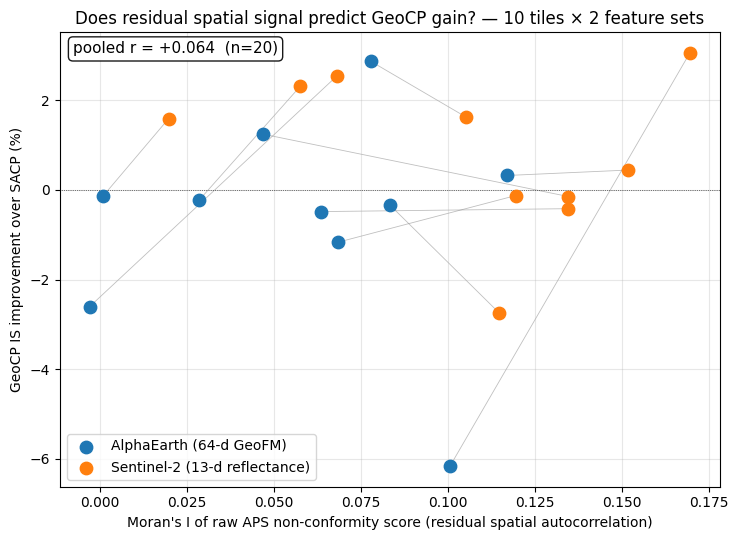

Saved /content/drive/MyDrive/sentinel2_landcover_pilot_10m/figures/headline_I_raw_vs_geocp_gain.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(7.5, 5.5))
ae_pts = df[['I_raw_ae','geocp_vs_sacp_ae']].dropna().values
s2_pts = df[['I_raw_s2','geocp_vs_sacp_s2']].dropna().values

ax.scatter(ae_pts[:,0], ae_pts[:,1], s=80, c='#1f77b4', label='AlphaEarth (64-d GeoFM)', zorder=3)
ax.scatter(s2_pts[:,0], s2_pts[:,1], s=80, c='#ff7f0e', label='Sentinel-2 (13-d reflectance)', zorder=3)

# Connect same-tile pairs with a thin line
for _, row in df.iterrows():
    if pd.notna(row['I_raw_ae']) and pd.notna(row['I_raw_s2']):
        ax.plot([row['I_raw_ae'], row['I_raw_s2']],
                [row['geocp_vs_sacp_ae'], row['geocp_vs_sacp_s2']],
                color='gray', lw=0.6, alpha=0.5, zorder=1)

ax.axhline(0, color='k', lw=0.5, ls=':')
ax.set_xlabel("Moran's I of raw APS non-conformity score (residual spatial autocorrelation)")
ax.set_ylabel('GeoCP IS improvement over SACP (%)')
ax.set_title('Does residual spatial signal predict GeoCP gain? — 10 tiles × 2 feature sets')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Pooled correlation
all_x = np.concatenate([ae_pts[:,0], s2_pts[:,0]])
all_y = np.concatenate([ae_pts[:,1], s2_pts[:,1]])
if len(all_x) >= 3:
    r = float(np.corrcoef(all_x, all_y)[0, 1])
    ax.text(0.02, 0.98, f'pooled r = {r:+.3f}  (n={len(all_x)})',
            transform=ax.transAxes, va='top', ha='left',
            fontsize=11, bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
out = f'{FIG_DIR}/headline_I_raw_vs_geocp_gain.png'
plt.savefig(out, dpi=160)
plt.show()
print('Saved', out)

### 8c. Interpretation checklist

- **Mean `I_raw`**: Sentinel-2 should be notably higher than AlphaEarth (that's the whole hypothesis — per-pixel features leave more spatial structure in the residual than context-aware features).
- **Mean `geocp_vs_sacp`**: Sentinel-2 should be more negative (= bigger improvement) than AlphaEarth. If Sentinel-2 is around −3 to −7 % and AlphaEarth is around 0 to −1 %, this is the clean version of the story.
- **Scatter shape**: if the 20 points form a rough downward trend (higher `I_raw` → more negative `geocp_vs_sacp`), the pooled r will be negative and the 'I_raw upper-bounds GeoCP gain' claim holds up.
- **Bandwidths picked**: look at `bw_s2` in the table above. If Sentinel-2 consistently picks smaller bandwidths (e.g. 30–100) while AlphaEarth picks 300–1000, that's further evidence that GeoCP's local mechanism actually engages on Sentinel-2 features and disengages on AlphaEarth features.

## 9. The per-pixel threshold $\hat q_j$ as extra information

Under the reframed narrative, SACP+GeoCP is **not** primarily a competitor to SACP on IS. It produces one additional output — the per-pixel conformal threshold field $\hat q_j$ — which SACP cannot, by construction. Mathematically,

$$\hat q_j \,=\, \hat F^{-1}(1-\alpha \mid z_j), \quad \hat F(t \mid z_j) \,=\, \sum_i \tilde w_{ji}\, \mathbb 1[s_i \le t], \quad \tilde w_{ji} \propto \exp\!\left(-\tfrac{\|z_j - z_i\|^2}{2h^2}\right).$$

That is, $\hat q_j$ is a **Nadaraya–Watson estimator of the spatially-varying conformal quantile function $Q(z) = F^{-1}(1-\alpha \mid z)$**, evaluated at each test location. SACP estimates only $\mathbb E_z[Q(z)]$ (a scalar); SACP+GeoCP estimates the entire function $Q(z)$ as a spatial field.

This section does two things:

- **9a**: For every (tile, feature_set), compute $\mathrm{sd}_z[\hat q_j]$ — the spatial standard deviation of the threshold field. This is a direct measure of how much the conformal procedure actually adapts to local geography. It is a better axis than `I_raw` for visualising the GeoCP effect, because it lives on the method's output rather than the input.
- **9b**: Rasterise $\hat q_j$ on the image grid for 2 selected tiles (one typical, one outlier), next to ground truth, prediction, and SACP's smoothed score. This is the headline figure of the reframed paper.

In [ ]:
# ---------------------------------------------------------------------
# 9a (v2). Recompute q_per_pixel DENSELY for all (tile, feature_set).
#
# v1 subsampled test to 10K for distance matrix tractability. v2 keeps
# the full test set (~200K pixels) via batched cdist, so visualizations
# can match SACP's Fig 2 density.
# ---------------------------------------------------------------------
import os, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from collections import Counter
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cdist

from geocp_rs.core import aps_scores, conformal_quantile, weighted_quantile
from geocp_rs.sacp import sacp_smooth

Q_CACHE_DIR = f'{WORK_DIR}/q_maps'
os.makedirs(Q_CACHE_DIR, exist_ok=True)

CACHE_VERSION = 2

def _weighted_quantile_batch(sorted_cal_scores, weights_batch_sorted, alpha):
    '''Vectorised (1-alpha)-weighted quantile for a batch of weight rows.

    sorted_cal_scores:    (n_cal,)   cal scores in ascending order
    weights_batch_sorted: (batch, n_cal)   already reordered to match cal sort
    Returns: (batch,) weighted quantile for each row.
    '''
    ws = weights_batch_sorted / weights_batch_sorted.sum(axis=1, keepdims=True)
    cum = np.cumsum(ws, axis=1)
    # first index where cum >= 1 - alpha
    k_star = np.argmax(cum >= (1.0 - alpha), axis=1)
    return sorted_cal_scores[k_star]

def compute_q_map(tile_key, feature_set, tile_dir, ckpt_dir,
                  seed=0, lmd=0.5, alpha=0.1,
                  max_cal=5000, max_test=10000,
                  batch_test=2000, force=False):
    '''Retrain XGBoost deterministically, compute q_per_pixel for EVERY
    test pixel (not just a subsample) via batched cdist.
    '''
    cache_path = f'{Q_CACHE_DIR}/{feature_set}__{tile_key}_seed{seed}.pkl'
    if os.path.exists(cache_path) and not force:
        blob = pickle.load(open(cache_path, 'rb'))
        if blob.get('version', 1) >= CACHE_VERSION:
            return blob
        # old-version cache -> fall through and rebuild

    main_ckpt = f'{ckpt_dir}/{tile_key}_seed{seed}.pkl'
    main = pickle.load(open(main_ckpt, 'rb'))
    best_bw = int(main['sacp_geocp']['bw'])

    arr = np.load(f'{tile_dir}/{tile_key}.npz')
    emb = arr['emb']; label = arr['label']
    H, W, D = emb.shape
    N = H * W
    flat_label = label.ravel()
    X_flat = emb.reshape(N, D)

    labeled_idx = np.where(flat_label > 0)[0]
    y_raw = flat_label[labeled_idx]
    counts = Counter(y_raw.tolist())
    rare = [c for c, cnt in counts.items() if cnt < 100]
    keep = ~np.isin(y_raw, rare)
    labeled_idx = labeled_idx[keep]; y_raw = y_raw[keep]
    X_lab = X_flat[labeled_idx]
    classes = sorted(np.unique(y_raw).tolist())
    K = len(classes)
    cls_remap = {c: i for i, c in enumerate(classes)}
    y = np.array([cls_remap[v] for v in y_raw])

    idx_pos = np.arange(len(y))
    idx_tr, idx_tmp = train_test_split(idx_pos, train_size=0.6,
                                        random_state=seed*100+42, stratify=y)
    idx_ca, idx_te  = train_test_split(idx_tmp, test_size=0.5,
                                        random_state=seed*100+42, stratify=y[idx_tmp])

    model = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        objective='multi:softprob', num_class=K,
        tree_method='hist', random_state=seed*100+42, verbosity=0)
    model.fit(X_lab[idx_tr], y[idx_tr])
    probs_ca = model.predict_proba(X_lab[idx_ca])
    probs_te = model.predict_proba(X_lab[idx_te])
    pred_te  = np.argmax(probs_te, axis=1)

    rng = np.random.RandomState(seed*100+42)
    cal_all  = aps_scores(probs_ca, rng=rng)
    test_all = aps_scores(probs_te, rng=rng)
    cal_true = aps_scores(probs_ca, y[idx_ca], rng=rng)

    cal_flat_idx  = labeled_idx[idx_ca]
    test_flat_idx = labeled_idx[idx_te]

    score_map = np.zeros((N, K), dtype=np.float64)
    score_map[cal_flat_idx]  = cal_all
    score_map[test_flat_idx] = test_all
    valid_idx = np.concatenate([cal_flat_idx, test_flat_idx])
    fused = sacp_smooth(score_map, H, W, valid_idx, lmd=lmd)

    fcu = np.array([fused[cal_flat_idx[e], int(y[idx_ca[e]])] for e in range(len(idx_ca))])
    ftu_full = fused[test_flat_idx]   # (n_test_full, K)

    # Global SACP threshold (for Std CP reference size)
    q_std = conformal_quantile(cal_true, alpha)
    q_sacp_global = conformal_quantile(fcu, alpha)

    # Subsample cal for GeoCP (distance matrix still needed; we only subsample cal)
    sub_ca = _stratified_sub(y[idx_ca], max_cal, seed*100+43)
    fcu_sub = fcu[sub_ca]
    coords_ca_sub = np.stack([cal_flat_idx[sub_ca] // W,
                              cal_flat_idx[sub_ca] %  W], axis=1).astype(float)

    # ---- Dense q_j via batched cdist over FULL test set ----
    n_test_full = len(test_flat_idx)
    coords_te_full = np.stack([test_flat_idx // W, test_flat_idx % W], axis=1).astype(float)

    order = np.argsort(fcu_sub)
    sorted_fcu = fcu_sub[order]

    q_full = np.empty(n_test_full, dtype=np.float64)
    for b in range(0, n_test_full, batch_test):
        be = min(b + batch_test, n_test_full)
        d = cdist(coords_te_full[b:be], coords_ca_sub)
        log_w = -0.5 * (d / best_bw) ** 2
        log_w -= log_w.max(axis=1, keepdims=True)
        w = np.exp(log_w)
        w_sorted = w[:, order]
        q_full[b:be] = _weighted_quantile_batch(sorted_fcu, w_sorted, alpha)

    # ---- Dense SACP score at predicted class ----
    sacp_score_full = ftu_full[np.arange(n_test_full), pred_te]

    # ---- Dense set-size maps: std / sacp / sacp+geocp ----
    set_size_std   = (test_all < q_std).sum(axis=1)                    # uses raw scores
    set_size_sacp  = (ftu_full  < q_sacp_global).sum(axis=1)            # uses fused + global
    set_size_geocp = (ftu_full  < q_full[:, None]).sum(axis=1)          # uses fused + per-pixel

    # Also keep the legacy subsampled arrays for backward compat
    sub_te = _stratified_sub(y[idx_te], max_test, seed*100+43)
    test_sub_flat_idx = test_flat_idx[sub_te]

    result = {
        'version':         CACHE_VERSION,
        'tile_key':        tile_key,
        'feature_set':     feature_set,
        'H': int(H), 'W': int(W),
        'best_bw':         best_bw,
        'alpha':           float(alpha),
        'esa_class_codes': classes,
        'label_full':      label,
        # subsampled (legacy)
        'q_per_pixel':       q_full[sub_te],
        'sacp_score_at_pred': sacp_score_full[sub_te],
        'test_sub_flat_idx': test_sub_flat_idx,
        'y_test_sub':        y[idx_te][sub_te],
        'pred_test_sub':     pred_te[sub_te],
        # DENSE (new in v2)
        'test_full_flat_idx': test_flat_idx,
        'pred_test_full':     pred_te,
        'y_test_full':        y[idx_te],
        'q_per_pixel_full':   q_full,
        'sacp_score_full':    sacp_score_full,
        'set_size_std':       set_size_std,
        'set_size_sacp':      set_size_sacp,
        'set_size_geocp':     set_size_geocp,
        'q_std':              float(q_std),
        'q_sacp_global':      float(q_sacp_global),
    }
    with open(cache_path, 'wb') as f:
        pickle.dump(result, f, protocol=pickle.HIGHEST_PROTOCOL)
    return result

# Run for all 20 (tile, feature_set) pairs
rows = []
for tk in TILES:
    for fs, td, cd in [('sentinel2',  TILE_DIR,    CKPT_DIR),
                        ('alphaearth', AE_TILE_DIR, AE_CKPT_DIR)]:
        if not os.path.exists(f'{td}/{tk}.npz'):
            print(f'{fs:10s} {tk:18s} SKIP (no .npz)')
            continue
        t0 = time.time()
        try:
            r = compute_q_map(tk, fs, td, cd)
        except FileNotFoundError as e:
            print(f'{fs:10s} {tk:18s} SKIP ({e})')
            continue
        q = r['q_per_pixel_full']
        rows.append({
            'tile': tk,
            'feature_set': fs,
            'best_bw': r['best_bw'],
            'n_test_full': int(len(q)),
            'mean_q':   float(np.mean(q)),
            'sd_q':     float(np.std(q)),
            'range_q':  float(q.max() - q.min()),
            'mean_size_std':   float(np.mean(r['set_size_std'])),
            'mean_size_sacp':  float(np.mean(r['set_size_sacp'])),
            'mean_size_geocp': float(np.mean(r['set_size_geocp'])),
        })
        print(f'{fs:10s} {tk:18s} bw={r["best_bw"]:>4d}  '
              f'n_test={len(q):>7d}  sd_q={np.std(q):.5f}  '
              f'size: std={np.mean(r["set_size_std"]):.2f} '
              f'sacp={np.mean(r["set_size_sacp"]):.2f} '
              f'geocp={np.mean(r["set_size_geocp"]):.2f}  '
              f'({time.time()-t0:.0f}s)')

df_q = pd.DataFrame(rows)
df_q.to_csv(f'{WORK_DIR}/sd_q_per_tile.csv', index=False)

print('\n=== sd(q_j) pivot (rows = tile, columns = feature_set) ===')
print(df_q.pivot(index='tile', columns='feature_set', values='sd_q').round(5).to_string())

print('\n=== Means across 10 tiles ===')
mg = df_q.groupby('feature_set').agg({
    'mean_q': 'mean', 'sd_q': 'mean',
    'mean_size_std': 'mean', 'mean_size_sacp': 'mean', 'mean_size_geocp': 'mean',
})
print(mg.round(4).to_string())

sentinel2  polk_iowa          bw=1000  n_test= 357247  sd_q=0.00318  size: std=1.54 sacp=1.36 geocp=1.37  (242s)
alphaearth polk_iowa          bw= 300  n_test= 273139  sd_q=0.01704  size: std=1.41 sacp=1.27 geocp=1.29  (280s)
sentinel2  lancaster_pa       bw=1000  n_test= 357510  sd_q=0.00115  size: std=1.62 sacp=1.42 geocp=1.42  (220s)
alphaearth lancaster_pa       bw= 300  n_test= 272927  sd_q=0.00851  size: std=1.33 sacp=1.21 geocp=1.20  (293s)
sentinel2  hartford_ct        bw= 300  n_test= 357514  sd_q=0.01344  size: std=1.64 sacp=1.46 geocp=1.46  (225s)
alphaearth hartford_ct        bw= 300  n_test= 272930  sd_q=0.01927  size: std=1.42 sacp=1.26 geocp=1.27  (304s)
sentinel2  everglades_fl      bw=1000  n_test= 357246  sd_q=0.00424  size: std=1.03 sacp=0.97 geocp=0.97  (192s)
alphaearth everglades_fl      bw= 300  n_test= 272930  sd_q=0.00436  size: std=0.90 sacp=0.90 geocp=0.90  (260s)
sentinel2  lubbock_tx         bw= 300  n_test= 357514  sd_q=0.01304  size: std=1.62 sacp=1.49 ge

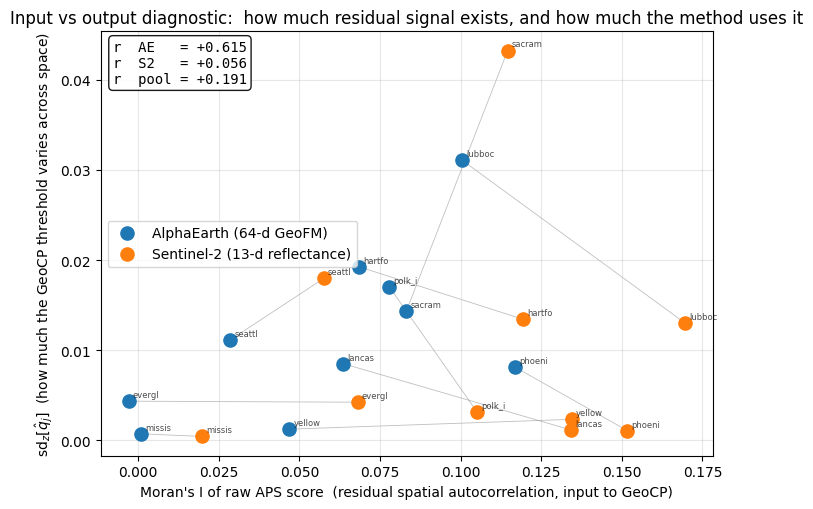

Saved /content/drive/MyDrive/sentinel2_landcover_pilot_10m/figures/I_raw_vs_sd_q.png


In [ ]:
# --- (I_raw, sd_q) scatter: direct axes for the reframed narrative ---
# This replaces the old (I_raw, IS-improvement) scatter with a cleaner one:
# sd_q measures how much the method actually varies q across space.
import matplotlib.pyplot as plt
import numpy as np

iraw_ae = dict(zip(df_ae['tile'], df_ae['I_raw']))
iraw_s2 = dict(zip(df_s2['tile'], df_s2['I_raw']))
df_q['I_raw'] = df_q.apply(
    lambda r: iraw_ae.get(r['tile'], float('nan')) if r['feature_set'] == 'alphaearth'
              else iraw_s2.get(r['tile'], float('nan')),
    axis=1)

fig, ax = plt.subplots(figsize=(7.2, 5.2))
for fs, color, label in [('alphaearth', '#1f77b4', 'AlphaEarth (64-d GeoFM)'),
                          ('sentinel2',  '#ff7f0e', 'Sentinel-2 (13-d reflectance)')]:
    g = df_q[df_q['feature_set'] == fs]
    ax.scatter(g['I_raw'], g['sd_q'], s=90, c=color, label=label, zorder=3)
    for _, row in g.iterrows():
        ax.annotate(row['tile'][:6], (row['I_raw'], row['sd_q']),
                     fontsize=6, alpha=0.7,
                     xytext=(3, 3), textcoords='offset points')

for tk in df_q['tile'].unique():
    sub = df_q[df_q['tile'] == tk]
    if len(sub) == 2:
        ax.plot(sub['I_raw'], sub['sd_q'], color='gray', lw=0.6, alpha=0.5, zorder=1)

ax.set_xlabel("Moran's I of raw APS score  (residual spatial autocorrelation, input to GeoCP)")
ax.set_ylabel(r'$\mathrm{sd}_z[\hat q_j]$  (how much the GeoCP threshold varies across space)')
ax.set_title('Input vs output diagnostic:  how much residual signal exists, and how much the method uses it')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

ae_v = df_q[df_q.feature_set=='alphaearth'][['I_raw','sd_q']].dropna().values
s2_v = df_q[df_q.feature_set=='sentinel2'][['I_raw','sd_q']].dropna().values
r_ae = float(np.corrcoef(ae_v[:,0], ae_v[:,1])[0,1]) if len(ae_v) >= 3 else float('nan')
r_s2 = float(np.corrcoef(s2_v[:,0], s2_v[:,1])[0,1]) if len(s2_v) >= 3 else float('nan')
all_v = np.vstack([ae_v, s2_v])
r_all = float(np.corrcoef(all_v[:,0], all_v[:,1])[0,1])
ax.text(0.02, 0.98,
        f'r  AE   = {r_ae:+.3f}\nr  S2   = {r_s2:+.3f}\nr  pool = {r_all:+.3f}',
        transform=ax.transAxes, va='top', ha='left',
        fontsize=10, family='monospace',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

plt.tight_layout()
out = f'{FIG_DIR}/I_raw_vs_sd_q.png'
plt.savefig(out, dpi=160)
plt.show()
print('Saved', out)

In [ ]:
# ---------------------------------------------------------------------
# 9b (v2). Dense raster visualization matching SACP Fig 2 conventions.
#
# Per tile, 2x5 panel:
#   row = feature_set (sentinel2 / alphaearth)
#   col 0: ESA WorldCover GT
#   col 1: XGBoost prediction     (dense, all test pixels)
#   col 2: SACP set size map      (global threshold tau)
#   col 3: SACP+GeoCP set size map (per-pixel q_j)
#   col 4: q_j local threshold    (the GeoCP deliverable)
# ---------------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

VIZ_TILES = list(TILES.keys())   # all 10 tiles

ESA_COLORS = {
    10:  '#006400',  20:  '#ffbb22', 30:  '#ffff4c', 40:  '#f096ff',
    50:  '#fa0000',  60:  '#b4b4b4', 70:  '#f0f0f0', 80:  '#0064c8',
    90:  '#0096a0',  95:  '#00cf75', 100: '#fae6a0',
}

def scatter_to_grid(values, flat_idx, H, W, fill=np.nan):
    out = np.full(H * W, fill, dtype=np.float64)
    out[flat_idx] = values
    return out.reshape(H, W)

def plot_tile(tile_key):
    fig, axes = plt.subplots(2, 5, figsize=(21, 9.5), constrained_layout=True)

    for row, fs in enumerate(['sentinel2', 'alphaearth']):
        try:
            r = compute_q_map(tile_key, fs,
                              TILE_DIR    if fs == 'sentinel2'  else AE_TILE_DIR,
                              CKPT_DIR    if fs == 'sentinel2'  else AE_CKPT_DIR)
        except FileNotFoundError:
            for c in range(5):
                axes[row, c].text(0.5, 0.5, f'{fs} not available',
                                  ha='center', va='center', transform=axes[row, c].transAxes)
                axes[row, c].set_axis_off()
            continue

        H, W     = r['H'], r['W']
        codes    = r['esa_class_codes']
        label_full = r['label_full']
        test_flat = np.asarray(r['test_full_flat_idx'])

        # Categorical cmap for ESA WorldCover
        color_list = [ESA_COLORS.get(c, '#999999') for c in codes]
        cat_cmap = ListedColormap(color_list)
        bounds   = list(range(len(codes) + 1))
        cat_norm = BoundaryNorm(bounds, cat_cmap.N)
        remap    = {c: i for i, c in enumerate(codes)}

        gt_remapped = np.full(label_full.shape, np.nan)
        for c, i in remap.items():
            gt_remapped[label_full == c] = i

        # Panel 0: ESA GT
        ax = axes[row, 0]
        ax.imshow(gt_remapped, cmap=cat_cmap, norm=cat_norm, interpolation='nearest')
        ax.set_title(f'{fs}  —  ESA WorldCover GT', fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])

        # Panel 1: Dense XGBoost prediction
        pred_raster = scatter_to_grid(r['pred_test_full'], test_flat, H, W)
        ax = axes[row, 1]
        ax.imshow(pred_raster, cmap=cat_cmap, norm=cat_norm, interpolation='nearest')
        ax.set_title(f'{fs}  —  XGBoost prediction', fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])

        # Shared set size scale (SACP & GeoCP use same scale so they are comparable)
        size_max = float(max(r['set_size_sacp'].max(), r['set_size_geocp'].max()))
        size_vmin = 0
        size_vmax = size_max

        # Panel 2: SACP set size
        size_sacp_raster = scatter_to_grid(r['set_size_sacp'], test_flat, H, W)
        ax = axes[row, 2]
        im = ax.imshow(size_sacp_raster, cmap='viridis',
                        vmin=size_vmin, vmax=size_vmax, interpolation='nearest')
        mean_sz_sacp = float(np.nanmean(r['set_size_sacp']))
        ax.set_title(f'{fs}  —  SACP set size (mean={mean_sz_sacp:.2f})', fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.045, pad=0.02)

        # Panel 3: SACP+GeoCP set size
        size_geocp_raster = scatter_to_grid(r['set_size_geocp'], test_flat, H, W)
        ax = axes[row, 3]
        im = ax.imshow(size_geocp_raster, cmap='viridis',
                        vmin=size_vmin, vmax=size_vmax, interpolation='nearest')
        mean_sz_geocp = float(np.nanmean(r['set_size_geocp']))
        ax.set_title(f'{fs}  —  SACP+GeoCP set size (mean={mean_sz_geocp:.2f})', fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.045, pad=0.02)

        # Panel 4: q_j local threshold
        q_raster = scatter_to_grid(r['q_per_pixel_full'], test_flat, H, W)
        q_vals = r['q_per_pixel_full']
        vmin_q, vmax_q = np.nanpercentile(q_vals, [2, 98])
        ax = axes[row, 4]
        im = ax.imshow(q_raster, cmap='magma', vmin=vmin_q, vmax=vmax_q,
                        interpolation='nearest')
        q_sd = float(np.std(q_vals))
        ax.set_title(r'{}  —  $\hat q_j$  (bw={}, sd={:.4f})'.format(fs, r['best_bw'], q_sd),
                     fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
        plt.colorbar(im, ax=ax, fraction=0.045, pad=0.02)

    fig.suptitle(f'Tile: {tile_key}  ({TILES[tile_key]["name"]})',
                 fontsize=14, y=1.02)
    out = f'{FIG_DIR}/qmap_{tile_key}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved', out)

for tk in VIZ_TILES:
    print(f'\n--- plotting {tk} ---')
    plot_tile(tk)


--- plotting polk_iowa ---


### 9c. Cross-tile summary figure — 10 tiles in one shot

A 10 rows $\times$ 10 columns composite figure. Each **row** is one tile; each pair of adjacent **columns** shows one quantity for Sentinel-2 (left) and AlphaEarth (right). Column groups left-to-right: ESA GT, XGBoost prediction, SACP set size (global $\hat\tau$), SACP+GeoCP set size (per-pixel $\hat q_j$), $\hat q_j$ field.

Color scales:
- GT and Pred use a **shared** ESA WorldCover categorical palette (global across all tiles — so the same class gets the same color everywhere)
- SACP size and GeoCP size share a **single** global `vmin=0, vmax=max(set_size_sacp, set_size_geocp across all tiles)` — apples-to-apples brightness comparison
- $\hat q_j$ uses **per-tile 2–98% percentile clipping** (since mean $\hat q_j$ differs across tiles by construction, a shared scale would wash out within-tile variation)

In [ ]:
# ---------------------------------------------------------------------
# 9c. Cross-tile summary figure — 10 tiles x 10 columns
# ---------------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm

# ---- Preload all 20 cached results ----
print('Loading cached q_maps for cross-tile figure...')
all_results = {}
for tk in TILES:
    for fs, td, cd in [('sentinel2',  TILE_DIR,    CKPT_DIR),
                        ('alphaearth', AE_TILE_DIR, AE_CKPT_DIR)]:
        try:
            all_results[(tk, fs)] = compute_q_map(tk, fs, td, cd)
        except FileNotFoundError:
            all_results[(tk, fs)] = None
            print(f'  missing: {tk} ({fs})')

valid = [v for v in all_results.values() if v is not None]
if not valid:
    raise RuntimeError('No q_maps available — run cell 28 (9a v2) first.')

# ---- Master ESA palette shared across all tiles ----
all_codes = sorted({c for r in valid for c in r['esa_class_codes']})
master_colors = [ESA_COLORS.get(c, '#999999') for c in all_codes]
master_cmap   = ListedColormap(master_colors)
master_bounds = list(range(len(all_codes) + 1))
master_norm   = BoundaryNorm(master_bounds, master_cmap.N)
master_remap  = {c: i for i, c in enumerate(all_codes)}
print(f'Master ESA codes across all tiles: {all_codes}')

# ---- Global size scale (SACP and GeoCP share vmin/vmax) ----
size_vmax = float(max(
    max(r['set_size_sacp'].max(), r['set_size_geocp'].max())
    for r in valid
))
print(f'Shared size vmax (SACP + GeoCP): {size_vmax}')

# ---- Layout: n_tiles rows x (5 quantities * 2 feature_sets) cols ----
tile_list = list(TILES.keys())
n_tiles   = len(tile_list)
quantity_names = ['ESA GT', 'Pred', 'SACP size', 'GeoCP size', r'$\hat q_j$']
fs_list   = ['sentinel2', 'alphaearth']
fs_labels = ['S2', 'AE']
n_cols    = len(quantity_names) * len(fs_list)   # 10

fig, axes = plt.subplots(
    n_tiles, n_cols,
    figsize=(n_cols * 1.6, n_tiles * 1.7),
    constrained_layout=True,
)

for row, tk in enumerate(tile_list):
    for q_idx, q_name in enumerate(quantity_names):
        for fs_idx, fs in enumerate(fs_list):
            col = q_idx * 2 + fs_idx
            ax = axes[row, col]
            ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_linewidth(0.3)

            r = all_results.get((tk, fs))
            if r is None:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                        transform=ax.transAxes, fontsize=8)
                continue

            H, W     = r['H'], r['W']
            test_flat = np.asarray(r['test_full_flat_idx'])
            label_full = r['label_full']

            if q_idx == 0:
                gt = np.full(label_full.shape, np.nan)
                for esa_code, gi in master_remap.items():
                    gt[label_full == esa_code] = gi
                ax.imshow(gt, cmap=master_cmap, norm=master_norm, interpolation='nearest')
            elif q_idx == 1:
                codes = r['esa_class_codes']
                pred_global = np.array([master_remap[codes[p]] for p in r['pred_test_full']])
                pred_raster = scatter_to_grid(pred_global, test_flat, H, W)
                ax.imshow(pred_raster, cmap=master_cmap, norm=master_norm, interpolation='nearest')
            elif q_idx == 2:
                raster = scatter_to_grid(r['set_size_sacp'], test_flat, H, W)
                ax.imshow(raster, cmap='viridis', vmin=0, vmax=size_vmax, interpolation='nearest')
            elif q_idx == 3:
                raster = scatter_to_grid(r['set_size_geocp'], test_flat, H, W)
                ax.imshow(raster, cmap='viridis', vmin=0, vmax=size_vmax, interpolation='nearest')
            else:   # q_idx == 4
                raster = scatter_to_grid(r['q_per_pixel_full'], test_flat, H, W)
                q_vals = r['q_per_pixel_full']
                vmin_q, vmax_q = np.nanpercentile(q_vals, [2, 98])
                ax.imshow(raster, cmap='magma', vmin=vmin_q, vmax=vmax_q, interpolation='nearest')

            if row == 0:
                ax.set_title(f'{q_name}\n({fs_labels[fs_idx]})', fontsize=8)
            if col == 0:
                ax.set_ylabel(tk, fontsize=8, rotation=0, ha='right', va='center', labelpad=6)

fig.suptitle(
    'Cross-tile summary  —  columns: ESA GT | Pred | SACP size | SACP+GeoCP size | '
    r'$\hat q_j$   (each quantity shown for Sentinel-2 then AlphaEarth)',
    fontsize=11, y=1.02,
)

out = f'{FIG_DIR}/qmap_cross_tile_summary.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved', out)

# Also print a quick numeric summary of SACP vs GeoCP size per tile
import pandas as pd
rows = []
for (tk, fs), r in all_results.items():
    if r is None: continue
    rows.append({
        'tile': tk,
        'feature_set': fs,
        'mean_size_sacp':  float(r['set_size_sacp'].mean()),
        'mean_size_geocp': float(r['set_size_geocp'].mean()),
        'delta_size':      float(r['set_size_geocp'].mean() - r['set_size_sacp'].mean()),
        'sd_q':            float(np.std(r['q_per_pixel_full'])),
    })
df_summary = pd.DataFrame(rows).sort_values(['feature_set','tile']).reset_index(drop=True)
print('\n=== Per-tile size comparison (sorted by feature_set) ===')
print(df_summary.round(4).to_string(index=False))

### 9e. Multiscale ablation — does GeoCP help on smaller study areas?

**Hypothesis**: On HSI datasets (IP 145², PU 610×340, SA 512×217), SACP+GeoCP delivers 2–7% IS improvement over SACP. These scenes are all **< 3 km wide**. On our 10 km × 10 km AlphaEarth/S2 tiles, GeoCP barely improves SACP. Maybe the effective study-area size is the confounding variable, not the feature set.

**Test**: Take a single tile (`lubbock_tx` AlphaEarth, 1000 × 1000 px = 10 × 10 km), center-crop it to **5 successively smaller patches** (500 m, 1 km, 2 km, 5 km, 10 km), and run the complete CP pipeline on each. Compare Std CP / SACP / SACP+GeoCP metrics as a function of patch size. This is a single-variable ablation — same .npz data, same classifier, same seed, only the spatial extent changes.

**What we'll learn** (independent of whether the hypothesis turns out to be right):
- If GeoCP improvement (%) increases monotonically as patch size shrinks → small study area genuinely helps
- If best bandwidth scales linearly with patch size → GeoCP adapts to the available extent
- If `sd_q` grows at small scales → the per-pixel threshold becomes meaningfully adaptive at small scales

Note: at small sizes ($S \le 200$), we no longer subsample cal, so we get full cal density by accident. This experiment therefore also partially tests 'does full cal density fix GeoCP?'.

In [3]:
# ---------------------------------------------------------------------
# 9e. Multiscale ablation on ALL 10 S2 tiles  (0.5 km – 5 km)
# 
# METHODOLOGICAL FIX: Bandwidth is now selected via 5-fold CV on the
# CALIBRATION subsample (not by minimising test-set IS, which would be
# test-set hyperparameter tuning). The test set is used exactly once
# per (tile, size) to report the final metrics at the CV-selected bw.
#
# Other fixes from the previous version:
#   - cdist computed ONCE per batch, reused across bw values (~7x speedup)
#   - Cal subsample capped at MSC_MAX_CAL=20000 for tractability at size=500
# ---------------------------------------------------------------------
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from collections import Counter
from sklearn.model_selection import train_test_split, KFold
from scipy.spatial.distance import cdist
from scipy.signal import convolve2d

from geocp_rs.core import aps_scores, conformal_quantile, weighted_quantile
from geocp_rs.sacp import sacp_smooth
from geocp_rs.metrics import coverage_and_size, interval_score

MSC_FS       = 'sentinel2'
MSC_TILEDIR  = TILE_DIR
MSC_SIZES    = [50, 100, 200, 500]              # 0.5, 1, 2, 5 km
MSC_BWGRID   = [3, 5, 10, 20, 50, 100]          # bw sweep (px)
MSC_MAX_CAL  = 20000                             # cap cal size to keep cdist tractable
MSC_CV_FOLDS = 5
ALPHA        = 0.1
LMD          = 0.5
SEED         = 0

def _morans_I_sparse(values_at_idx, flat_idx, H, W):
    S = np.full((H, W), np.nan)
    S.flat[flat_idx] = values_at_idx
    mask = ~np.isnan(S)
    mean = np.nanmean(S)
    Sm = np.where(mask, S - mean, 0.0)
    kernel = np.ones((3, 3)); kernel[1, 1] = 0.0
    nbr_sum = convolve2d(Sm, kernel, mode='same', boundary='fill', fillvalue=0.0)
    nbr_cnt = convolve2d(mask.astype(float), kernel, mode='same', boundary='fill', fillvalue=0.0)
    num = float((Sm[mask] * nbr_sum[mask]).sum())
    den = float((Sm[mask] ** 2).sum())
    W_sum = float(nbr_cnt[mask].sum())
    Nm = int(mask.sum())
    if den == 0 or W_sum == 0:
        return float('nan')
    return (Nm / W_sum) * (num / den)

def _stratified_sub_local(labels, n, seed):
    if n is None or n >= len(labels):
        return np.arange(len(labels))
    uniq, per_cls_counts = np.unique(labels, return_counts=True)
    per_cls_n = np.maximum(1, (n * per_cls_counts / per_cls_counts.sum()).astype(int))
    rng_sub = np.random.RandomState(seed)
    out = []
    for c, nc in zip(uniq, per_cls_n):
        pool = np.where(labels == c)[0]
        out.append(pool if len(pool) <= nc else rng_sub.choice(pool, size=nc, replace=False))
    return np.concatenate(out)

def _vectorised_weighted_quantile(sorted_scores, d_matrix, order, bw, alpha):
    '''Given distance matrix d (rows of test queries, cols = cal), return
    (1-alpha) weighted quantile per row using Gaussian kernel of bandwidth bw.
    sorted_scores: cal scores sorted ascending (same length as cols of d).
    order:         argsort index that sorted cal scores.
    '''
    log_w = -0.5 * (d_matrix / bw) ** 2
    log_w -= log_w.max(axis=1, keepdims=True)
    w = np.exp(log_w)
    w_sorted = w[:, order]
    ws = w_sorted / w_sorted.sum(axis=1, keepdims=True)
    cum = np.cumsum(ws, axis=1)
    k_star = np.argmax(cum >= (1 - alpha), axis=1)
    return sorted_scores[k_star]

def run_pipeline_on_patch(emb, label, size_px, seed=0, alpha=0.1, lmd=0.5,
                          bw_grid=MSC_BWGRID, max_cal=MSC_MAX_CAL,
                          cv_folds=MSC_CV_FOLDS):
    '''Full CP pipeline on one (emb, label) patch.

    BANDWIDTH SELECTION: 5-fold CV on calibration subsample.
    Test set is used ONCE at the CV-selected bw.
    '''
    H, W, D = emb.shape
    N = H * W
    flat_label = label.ravel()
    X_flat = emb.reshape(N, D)

    labeled_idx = np.where(flat_label > 0)[0]
    y_raw = flat_label[labeled_idx]
    counts = Counter(y_raw.tolist())
    min_count = int(max(10, min(100, N // 500)))
    rare = [c for c, cnt in counts.items() if cnt < min_count]
    keep = ~np.isin(y_raw, rare)
    labeled_idx = labeled_idx[keep]; y_raw = y_raw[keep]
    X_lab = X_flat[labeled_idx]
    classes = sorted(np.unique(y_raw).tolist())
    K = len(classes)
    if K < 2 or len(y_raw) < 200:
        return None
    cls_remap = {c: i for i, c in enumerate(classes)}
    y = np.array([cls_remap[v] for v in y_raw])

    idx_pos = np.arange(len(y))
    idx_tr, idx_tmp = train_test_split(idx_pos, train_size=0.6,
                                        random_state=seed*100+42, stratify=y)
    idx_ca, idx_te  = train_test_split(idx_tmp, test_size=0.5,
                                        random_state=seed*100+42, stratify=y[idx_tmp])

    model = xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        objective='multi:softprob', num_class=K,
        tree_method='hist', random_state=seed*100+42, verbosity=0)
    model.fit(X_lab[idx_tr], y[idx_tr])
    probs_ca = model.predict_proba(X_lab[idx_ca])
    probs_te = model.predict_proba(X_lab[idx_te])
    acc = float(np.mean(np.argmax(probs_te, axis=1) == y[idx_te]))

    rng = np.random.RandomState(seed*100+42)
    cal_all  = aps_scores(probs_ca, rng=rng)
    test_all = aps_scores(probs_te, rng=rng)
    cal_true = aps_scores(probs_ca, y[idx_ca], rng=rng)

    cal_flat_idx  = labeled_idx[idx_ca]
    test_flat_idx = labeled_idx[idx_te]

    score_map = np.zeros((N, K), dtype=np.float64)
    score_map[cal_flat_idx]  = cal_all
    score_map[test_flat_idx] = test_all
    valid_idx = np.concatenate([cal_flat_idx, test_flat_idx])
    fused = sacp_smooth(score_map, H, W, valid_idx, lmd=lmd)

    fcu = np.array([fused[cal_flat_idx[e], int(y[idx_ca[e]])] for e in range(len(idx_ca))])
    ftu = fused[test_flat_idx]

    test_raw_true = np.array([test_all[e, int(y[idx_te[e]])] for e in range(len(idx_te))])
    I_raw = _morans_I_sparse(test_raw_true, test_flat_idx, H, W)

    # Standard CP (no bw)
    q_std = conformal_quantile(cal_true, alpha)
    ps_std = [np.where(test_all[i] < q_std)[0].tolist() for i in range(len(idx_te))]
    cov_std, sz_std = coverage_and_size(ps_std, y[idx_te])
    is_std = interval_score(ps_std, y[idx_te], alpha)

    # SACP (global smoothed quantile, no bw)
    q_sacp = conformal_quantile(fcu, alpha)
    ps_sacp = [np.where(ftu[i] < q_sacp)[0].tolist() for i in range(len(idx_te))]
    cov_sacp, sz_sacp = coverage_and_size(ps_sacp, y[idx_te])
    is_sacp = interval_score(ps_sacp, y[idx_te], alpha)

    # ------------------------------------------------------------
    # GeoCP: Phase 1 — 5-fold CV on cal subsample to pick best_bw
    # ------------------------------------------------------------
    sub_ca = _stratified_sub_local(y[idx_ca], max_cal, seed*100+43)
    fcu_sub = fcu[sub_ca]
    y_ca_sub = y[idx_ca][sub_ca]
    cal_sub_flat_idx = cal_flat_idx[sub_ca]
    coords_ca = np.stack([cal_sub_flat_idx // W, cal_sub_flat_idx % W], 1).astype(float)

    bws = [b for b in bw_grid if b < size_px * 0.8]
    if not bws:
        bws = [max(2, size_px // 20)]

    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=seed)
    cv_is = {bw: [] for bw in bws}
    for f_tr_idx, f_val_idx in kf.split(np.arange(len(sub_ca))):
        fcu_tr  = fcu_sub[f_tr_idx]
        order_tr = np.argsort(fcu_tr)
        sorted_tr = fcu_tr[order_tr]
        fcu_val_all = fused[cal_sub_flat_idx[f_val_idx]]     # (n_val, K)
        y_cv_val   = y_ca_sub[f_val_idx]
        d_cv = cdist(coords_ca[f_val_idx], coords_ca[f_tr_idx])
        for bw in bws:
            q_val = _vectorised_weighted_quantile(sorted_tr, d_cv, order_tr, bw, alpha)
            ps_cv = [np.where(fcu_val_all[i] < q_val[i])[0].tolist()
                     for i in range(len(f_val_idx))]
            cv_is[bw].append(interval_score(ps_cv, y_cv_val, alpha))
    cv_is_mean = {bw: float(np.mean(vs)) for bw, vs in cv_is.items()}
    best_bw = int(min(bws, key=lambda b: cv_is_mean[b]))

    # ------------------------------------------------------------
    # GeoCP: Phase 2 — evaluate on test set at best_bw (CV-selected)
    # ------------------------------------------------------------
    order_test = np.argsort(fcu_sub)
    sorted_fcu_test = fcu_sub[order_test]
    coords_te = np.stack([test_flat_idx // W, test_flat_idx % W], 1).astype(float)

    n_te = len(test_flat_idx)
    batch_test = min(2000, max(200, n_te))
    q_j_test = np.empty(n_te)
    for b in range(0, n_te, batch_test):
        be = min(b + batch_test, n_te)
        d = cdist(coords_te[b:be], coords_ca)
        q_j_test[b:be] = _vectorised_weighted_quantile(
            sorted_fcu_test, d, order_test, best_bw, alpha)

    ps_g = [np.where(ftu[i] < q_j_test[i])[0].tolist() for i in range(n_te)]
    cov_g, sz_g = coverage_and_size(ps_g, y[idx_te])
    is_g = interval_score(ps_g, y[idx_te], alpha)
    sd_q = float(np.std(q_j_test))

    return dict(
        size_px=size_px, size_km=size_px * 0.01,
        H=H, W=W, N=N,
        n_labeled=len(y), n_train=len(idx_tr),
        n_cal=len(idx_ca), n_test=len(idx_te),
        n_cal_used=len(sub_ca),
        n_classes=K,
        accuracy=acc, I_raw=I_raw,
        std_cov=cov_std, std_size=sz_std, std_is=is_std,
        sacp_cov=cov_sacp, sacp_size=sz_sacp, sacp_is=is_sacp,
        geocp_bw=best_bw,
        geocp_cov=cov_g, geocp_size=sz_g, geocp_is=is_g, geocp_sd_q=sd_q,
        cv_is_mean=cv_is_mean,
    )

# ---- Run all 10 tiles x all sizes ----
print('=' * 74)
print(f'Multiscale ablation on {len(TILES)} tiles x {len(MSC_SIZES)} sizes ({MSC_FS})')
print(f'Bandwidth selection: {MSC_CV_FOLDS}-fold CV on calibration subsample (max {MSC_MAX_CAL})')
print(f'Test set is used only once per (tile, size) at the CV-selected bandwidth.')
print('=' * 74)

all_results = []
total_t0 = time.time()

for tile_key in TILES:
    npz_path = f'{MSC_TILEDIR}/{tile_key}.npz'
    if not os.path.exists(npz_path):
        print(f'\n[SKIP] {tile_key}: npz not found')
        continue
    print(f'\n=== {tile_key} ===')
    arr = np.load(npz_path)
    emb_full, label_full = arr['emb'], arr['label']
    H_full, W_full = label_full.shape

    for S in MSC_SIZES:
        Seff = min(S, H_full, W_full)
        r0 = H_full // 2 - Seff // 2
        c0 = W_full // 2 - Seff // 2
        emb_sub   = emb_full[r0:r0+Seff, c0:c0+Seff]
        label_sub = label_full[r0:r0+Seff, c0:c0+Seff]
        t0 = time.time()
        res = run_pipeline_on_patch(emb_sub, label_sub, Seff,
                                     seed=SEED, alpha=ALPHA, lmd=LMD,
                                     bw_grid=MSC_BWGRID, max_cal=MSC_MAX_CAL,
                                     cv_folds=MSC_CV_FOLDS)
        dt = time.time() - t0
        if res is None:
            print(f'  {Seff:>4d} px | {Seff*0.01:4.2f} km | SKIPPED (too few samples/classes)')
            continue
        res['tile'] = tile_key
        all_results.append(res)
        gvs_sacp = 100*(res['sacp_is'] - res['geocp_is'])/res['sacp_is']
        gvs_std  = 100*(res['std_is']  - res['geocp_is'])/res['std_is']
        print(f'  {Seff:>4d} px | {Seff*0.01:4.2f} km | {dt:>5.0f}s | '
              f'K={res["n_classes"]} n_cal={res["n_cal_used"]:>6d} n_te={res["n_test"]:>6d} | '
              f'acc={res["accuracy"]:.3f} I_raw={res["I_raw"]:+.3f} | '
              f'Std={res["std_is"]:.3f} SACP={res["sacp_is"]:.3f} GeoCP={res["geocp_is"]:.3f} | '
              f'vs_sacp={gvs_sacp:+5.2f}% vs_std={gvs_std:+5.2f}% | '
              f'cv_bw={res["geocp_bw"]:>3d} sd_q={res["geocp_sd_q"]:.4f}')

print(f'\n==== total runtime {time.time()-total_t0:.0f}s ====')

if not all_results:
    raise RuntimeError('No successful results')

df_msc = pd.DataFrame([{
    'tile':        r['tile'],
    'size_km':     r['size_km'],
    'size_px':     r['size_px'],
    'n_cal':       r['n_cal_used'],
    'n_test':      r['n_test'],
    'n_classes':   r['n_classes'],
    'accuracy':    r['accuracy'],
    'I_raw':       r['I_raw'],
    'std_is':      r['std_is'],
    'sacp_is':     r['sacp_is'],
    'geocp_is':    r['geocp_is'],
    'vs_sacp_pct': 100*(r['sacp_is'] - r['geocp_is'])/r['sacp_is'],
    'vs_std_pct':  100*(r['std_is']  - r['geocp_is'])/r['std_is'],
    'cv_bw_px':    r['geocp_bw'],
    'sd_q':        r['geocp_sd_q'],
} for r in all_results])

df_msc.to_csv(f'{WORK_DIR}/multiscale_all_tiles_s2.csv', index=False)
print(f'\nSaved {WORK_DIR}/multiscale_all_tiles_s2.csv')

print('\n=== Summary by size (mean ± std across tiles) ===')
summary_sacp = df_msc.groupby('size_km').agg(
    n_tiles=('tile', 'count'),
    vs_sacp_mean=('vs_sacp_pct', 'mean'),
    vs_sacp_std=('vs_sacp_pct', 'std'),
    vs_sacp_min=('vs_sacp_pct', 'min'),
    vs_sacp_max=('vs_sacp_pct', 'max'),
    sd_q_mean=('sd_q', 'mean'),
    cv_bw_mean=('cv_bw_px', 'mean'),
)
print(summary_sacp.round(3).to_string())

# ---- 2x2 summary figure ----
fig, axes = plt.subplots(2, 2, figsize=(13, 10), constrained_layout=True)

ax = axes[0, 0]
for tile_key, g in df_msc.groupby('tile'):
    g = g.sort_values('size_km')
    ax.plot(g['size_km'], g['vs_sacp_pct'], 'o-', color='gray', alpha=0.5, lw=1)
mean_by_size = df_msc.groupby('size_km')['vs_sacp_pct'].mean()
std_by_size  = df_msc.groupby('size_km')['vs_sacp_pct'].std()
ax.errorbar(mean_by_size.index, mean_by_size.values, yerr=std_by_size.values,
             color='tab:red', lw=2.5, marker='o', markersize=10, capsize=5,
             label='mean ± std across tiles')
ax.axhline(0, color='k', lw=0.5)
ax.set_xscale('log')
ax.set_xlabel('Study area size (km)')
ax.set_ylabel('GeoCP vs SACP (%)   [CV-selected bw]')
ax.set_title('GeoCP relative improvement vs study area size')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
for tile_key, g in df_msc.groupby('tile'):
    g = g.sort_values('size_km')
    ax.plot(g['size_km'], g['vs_std_pct'], 'o-', color='gray', alpha=0.5, lw=1)
mean_by_size2 = df_msc.groupby('size_km')['vs_std_pct'].mean()
std_by_size2  = df_msc.groupby('size_km')['vs_std_pct'].std()
ax.errorbar(mean_by_size2.index, mean_by_size2.values, yerr=std_by_size2.values,
             color='tab:blue', lw=2.5, marker='o', markersize=10, capsize=5,
             label='mean ± std across tiles')
ax.axhline(0, color='k', lw=0.5)
ax.set_xscale('log')
ax.set_xlabel('Study area size (km)')
ax.set_ylabel('GeoCP vs Standard CP (%)   [CV-selected bw]')
ax.set_title('GeoCP improvement over Standard CP vs study area size')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
for tile_key, g in df_msc.groupby('tile'):
    g = g.sort_values('size_km')
    ax.plot(g['size_km'], g['sd_q'], 'o-', color='gray', alpha=0.5, lw=1)
mean_sdq = df_msc.groupby('size_km')['sd_q'].mean()
ax.plot(mean_sdq.index, mean_sdq.values,
         color='tab:purple', lw=2.5, marker='o', markersize=10, label='mean')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Study area size (km)')
ax.set_ylabel(r'$\mathrm{sd}_z[\hat q_j]$  at CV-selected bw')
ax.set_title('Per-pixel threshold spatial variation vs study area size')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

ax = axes[1, 1]
df_msc['cv_bw_km'] = df_msc['cv_bw_px'] * 0.01
for tile_key, g in df_msc.groupby('tile'):
    g = g.sort_values('size_km')
    ax.plot(g['size_km'], g['cv_bw_km'], 'o-', color='gray', alpha=0.5, lw=1)
mean_bw_km = df_msc.groupby('size_km')['cv_bw_km'].mean()
ax.plot(mean_bw_km.index, mean_bw_km.values,
         color='tab:green', lw=2.5, marker='o', markersize=10, label='mean CV-selected')
sizes_arr = sorted(df_msc['size_km'].unique())
ax.plot(sizes_arr, sizes_arr, ':', color='black', alpha=0.5, label='bw = size')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Study area size (km)')
ax.set_ylabel('CV-selected bandwidth (km)')
ax.set_title('CV-selected bandwidth vs study area size')
ax.legend()
ax.grid(True, alpha=0.3, which='both')

fig.suptitle(
    f'Multiscale ablation: {len(TILES)} S2 tiles x {len(MSC_SIZES)} sizes  '
    f'(bw chosen by {MSC_CV_FOLDS}-fold CV on cal; test used once)',
    fontsize=13, y=1.02,
)
out = f'{FIG_DIR}/multiscale_all_tiles_s2.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'\nSaved {out}')

Multiscale ablation on lubbock_tx / sentinel2
Full tile shape: 1337 × 1337  (embed dim = 13)

--- size = 50 px = 0.50 km ---
    patch shape: (50, 50, 13)
    elapsed=5s  n_cal=499  n_test=499  K=4
    acc=0.838  I_raw=-0.0025
    Std IS=3.745  SACP IS=3.377  GeoCP IS=3.379  (bw=20)
    GeoCP vs SACP = -0.06%   vs Std = +9.79%   sd_q=0.01179

--- size = 100 px = 1.00 km ---
    patch shape: (100, 100, 13)
    elapsed=2s  n_cal=1999  n_test=1999  K=4
    acc=0.808  I_raw=+0.0576
    Std IS=3.523  SACP IS=3.332  GeoCP IS=3.375  (bw=50)
    GeoCP vs SACP = -1.28%   vs Std = +4.20%   sd_q=0.00827

--- size = 200 px = 2.00 km ---
    patch shape: (200, 200, 13)
    elapsed=20s  n_cal=7997  n_test=7997  K=4
    acc=0.800  I_raw=+0.1048
    Std IS=3.483  SACP IS=3.245  GeoCP IS=3.169  (bw=20)
    GeoCP vs SACP = +2.33%   vs Std = +9.01%   sd_q=0.04162

--- size = 500 px = 5.00 km ---
    patch shape: (500, 500, 13)
    elapsed=945s  n_cal=50000  n_test=50000  K=7
    acc=0.785  I_raw=+0.1454


KeyboardInterrupt: 

## 10. Optional — package comparison artifacts for download

In [ ]:
import shutil
bundle_dir = f'{WORK_DIR}/bundle'
os.makedirs(bundle_dir, exist_ok=True)
for f in ['per_tile_s2.csv', 'per_tile_ae.csv', 'comparison_ae_vs_s2.csv']:
    src = f'{WORK_DIR}/{f}'
    if os.path.exists(src):
        shutil.copy(src, f'{bundle_dir}/{f}')
shutil.copytree(FIG_DIR, f'{bundle_dir}/figures', dirs_exist_ok=True)

zip_path = f'{WORK_DIR}/ae_vs_s2_bundle'
shutil.make_archive(zip_path, 'zip', bundle_dir)
print('Bundle at', zip_path + '.zip')
try:
    from google.colab import files
    files.download(zip_path + '.zip')
except Exception:
    print('Not in Colab — download manually from Drive.')

Bundle at /content/drive/MyDrive/sentinel2_landcover_pilot_10m/ae_vs_s2_bundle.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>